## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [4]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

data_dir = #'/project/InTEM_GHG/inversion/PARIS_results_sharing/'

model_filenames = {'intem_inner':'InTEM/InTEM_NAME_EUROPE_EdgarInnerBoxes',
                   'intem_outer':'InTEM/InTEM_NAME_EUROPE_EdgarOuterBoxes',
                   'intem_fixedbaseline':'InTEM/InTEM_NAME_EUROPE_fixedbaseline',
                  'elris':'ELRIS/ELRIS_NAME_EUROPE_EDGAR_11regions_4hourly',
                  'elris_fixedbaseline':'ELRIS/ELRIS_NAME_EUROPE_EDGAR_InTEMobs_and_bg_19Feb2024*'}

model_labels = {'intem_inner':'InTEM EDGAR inner',
                   'intem_outer':'InTEM EDGAR inner and outer',
                   'intem_fixedbaseline':'InTEM fixed baseline',
                  'elris':'ELRIS',
                  'elris_fixedbaseline':'ELRIS InTEM baseline and obs'}

model_colors = {'intem_inner':['darkblue','dodgerblue'],
                'intem_outer':['firebrick','darkorange'],
                'intem_fixedbaseline':['darkgreen','green'],
                'elris':['purple','mediumpurple'],
                'elris_fixedbaseline':['purple','mediumpurple']}

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [13]:
###################################
### edit variables in this block
species = 'hfc134a'
plot_regions = ['IRELAND','UK','FRANCE','GERMANY'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
models = ['intem_fixedbaseline','elris_fixedbaseline']#'rhime','elris']
start_date = '2018-01-01' #inclusive
end_date = '2023-01-01' #not inclusive
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames)

ds_all_flux_scaled = func.slice_flux(ds_all_flux.copy(),start_date,end_date,scale_units=True,
                                species=species)


Attempting to read data from intem_fixedbaseline
Done!

Attempting to read data from elris_fixedbaseline
Done!

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1000000.0

Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1000000.0
Scaling covariance units in elris_fixedbaseline by 1000000000000.0


#### Timeseries of country fluxes:

NOTE: If all the data is not within axis limits, adjust the set_ylim parameter


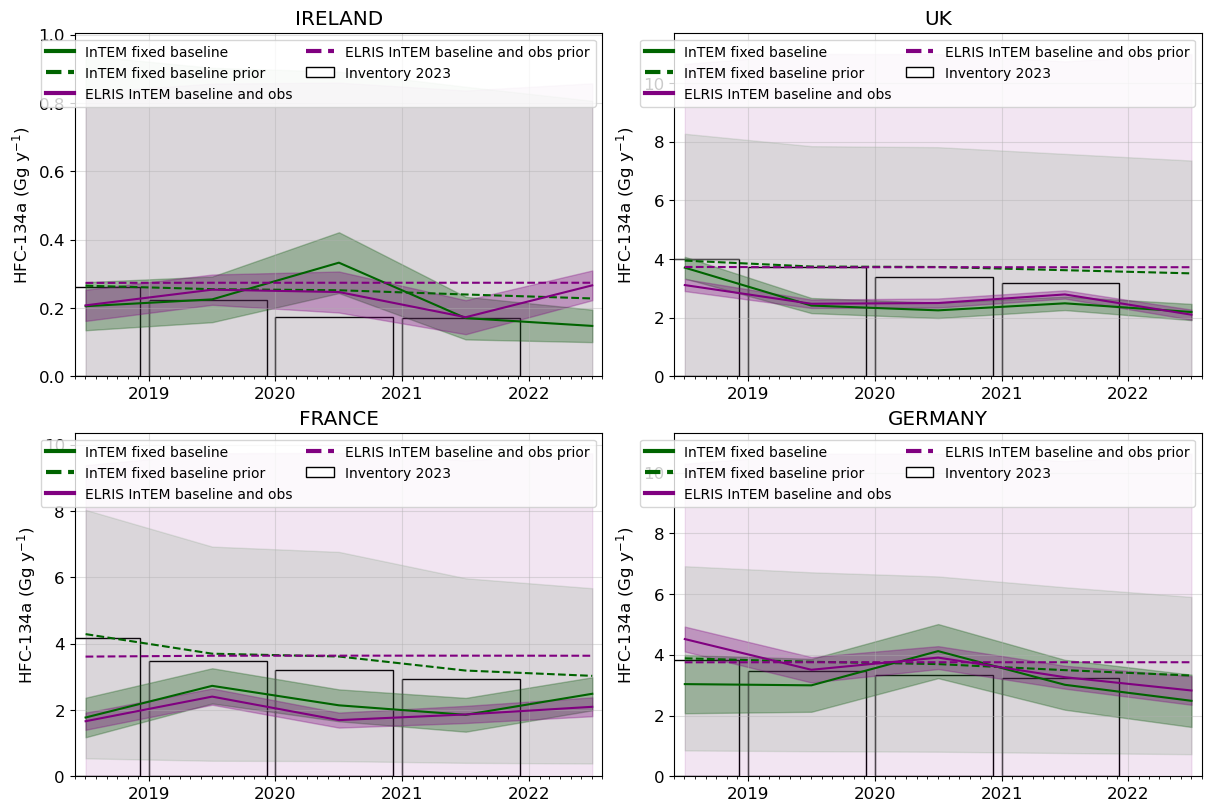

In [14]:
###################################
### edit variables in this block
plot_inventory = True
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,data_dir,fix_y_axes)

Save plot here:

In [23]:
#output_path = '/home/h02/aramsden/results/PARIS_results_comparison/fixed_baseline/InTEM_Feb2024_E-D_fixed_baseline_comparison_countryfluxes.png'

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [15]:
###################################
### edit variables in this block
species = 'hfc134a' 
site = 'MHD'
models = ['elris_fixedbaseline','intem_fixedbaseline']#'rhime',]
start_date = '2018-01-01' #inclusive
end_date = '2019-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs          - total observed mole fraction
# uYobs         - total observed mole fraction uncertainty
# Yapriori      - prior total mole fraction
# Yapost        - posterior total mole fraction
# YaprioriBC    - prior baseline
# YapostBC      - posterior baseline
# Ybias         - posterior bias added to site
# YaprioriOuter - prior mole fractions only from outer regions
# YapostOuter   - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,model_filenames)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)


Attempting to read data from elris_fixedbaseline
Done!

Attempting to read data from intem_fixedbaseline
Done!

Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1e-12

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1e-12


#### Timeseries plot, separated by model:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


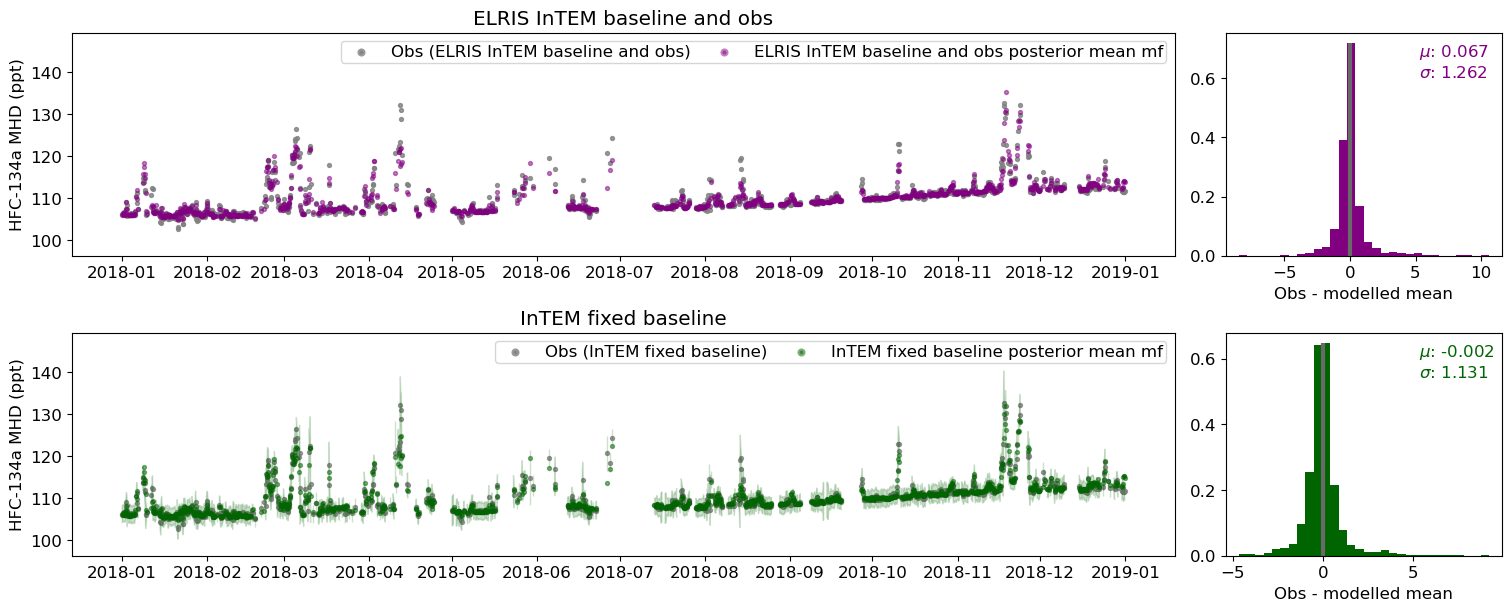

In [16]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'])

#### Timeseries plot, all models together:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


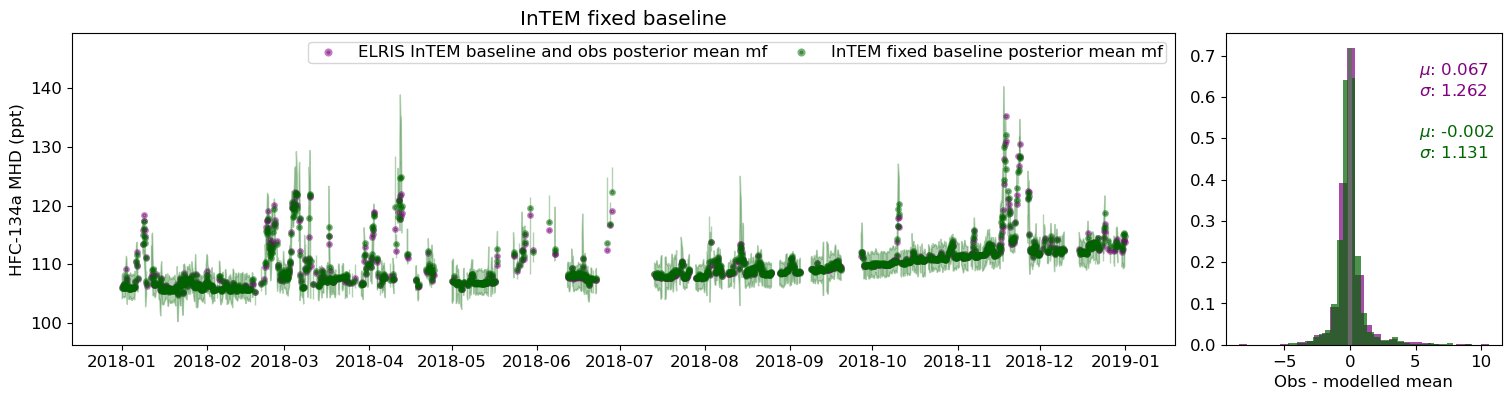

In [17]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Absolute differences between two models:

NOTE: If all the data is not within axis limits, adjust the set_ylim
NOTE: If annotations in the histograms are not displaying correctly, adjust annotate_coords.


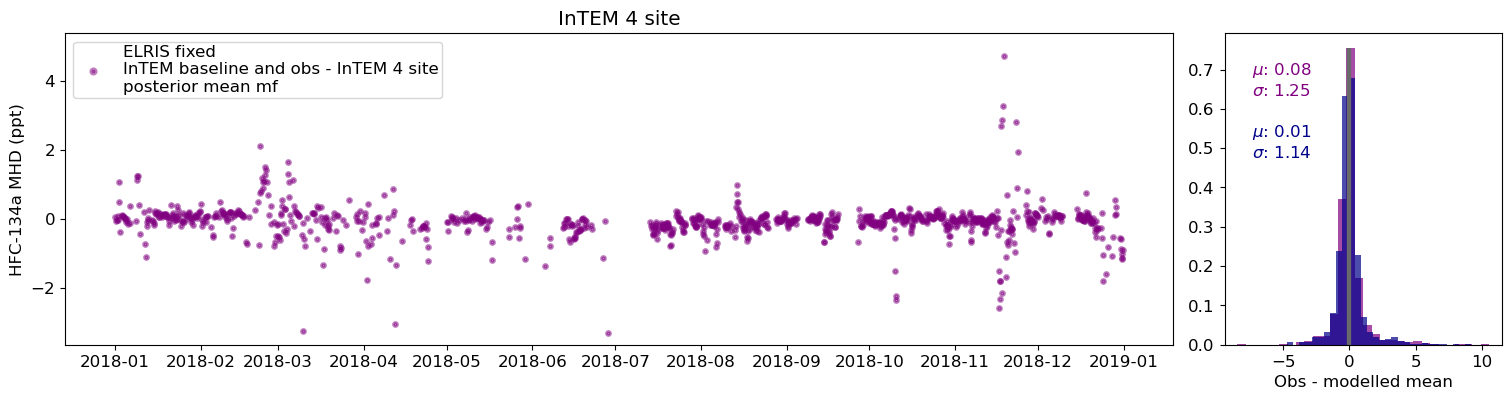

In [27]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'])

#### Calculate and plot stats for the fit to obs:


Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1e-12

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1e-12

Pearson correlation coefficient:
{'CMN': {'elris_fixedbaseline': 0.712, 'intem_fixedbaseline': 0.709},
 'JFJ': {'elris_fixedbaseline': 0.82, 'intem_fixedbaseline': 0.826},
 'MHD': {'elris_fixedbaseline': 0.948, 'intem_fixedbaseline': 0.959},
 'TAC': {'elris_fixedbaseline': 0.765, 'intem_fixedbaseline': 0.774}}

Normalised RMSE
{'CMN': {'elris_fixedbaseline': 0.035, 'intem_fixedbaseline': 0.035},
 'JFJ': {'elris_fixedbaseline': 0.025, 'intem_fixedbaseline': 0.025},
 'MHD': {'elris_fixedbaseline': 0.011, 'intem_fixedbaseline': 0.01},
 'TAC': {'elris_fixedbaseline': 0.041, 'intem_fixedbaseline': 0.044}}


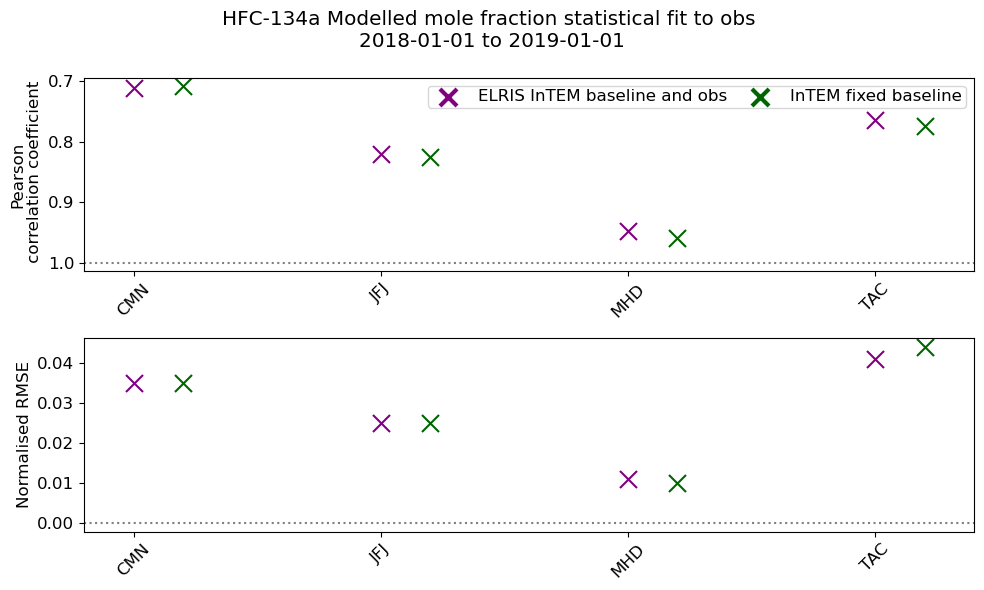

In [19]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [29]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [20]:
###################################
### edit variables in this block
species = 'hfc134a'
start_date = '2018-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2023-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = ['intem_fixedbaseline','elris_fixedbaseline']#,'rhime','elris_name']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames)

ds_all_flux_scaled = func.slice_flux(ds_all_flux.copy(),start_date,end_date,scale_units=True,
                                species=species)


Attempting to read data from intem_fixedbaseline
Done!

Attempting to read data from elris_fixedbaseline
Done!

Masking data from intem_fixedbaseline
Scaling intem_fixedbaseline units by 1000000.0

Masking data from elris_fixedbaseline
Scaling elris_fixedbaseline units by 1000000.0
Scaling covariance units in elris_fixedbaseline by 1000000000000.0


##### Prior and posterior fluxes for all models:

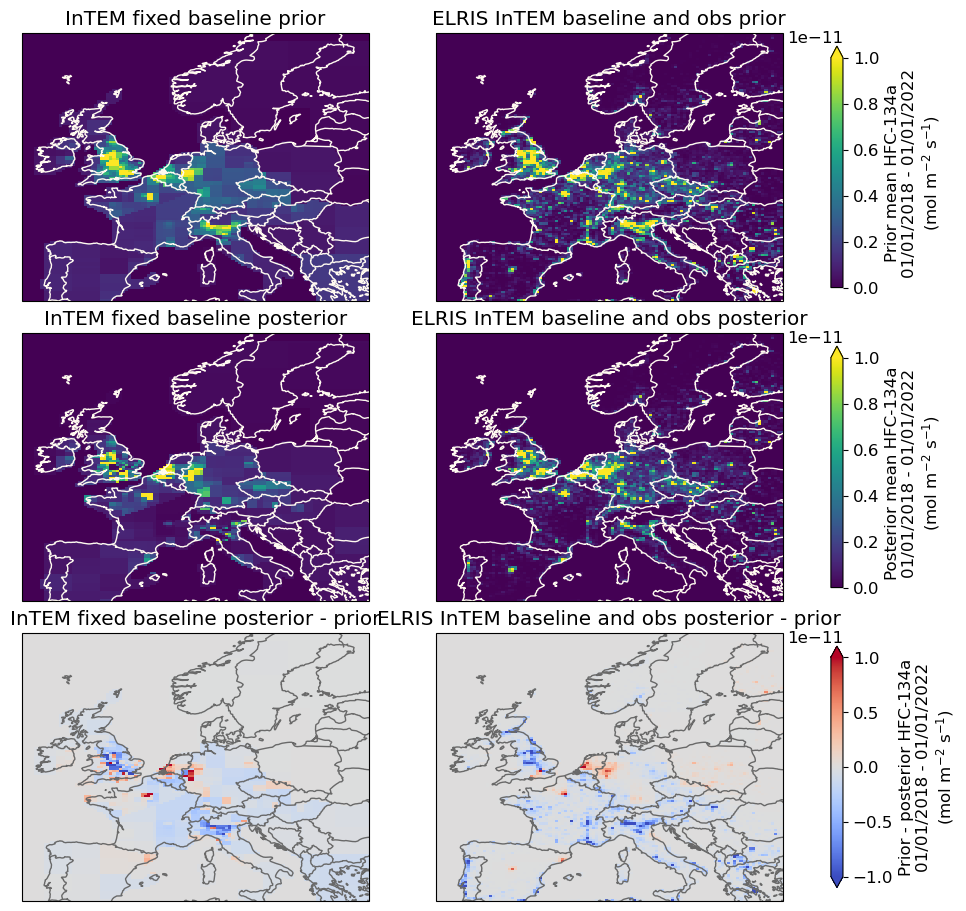

In [21]:
###################################
### edit variables in this block
plot_area = 'CWEU' #options for: UK, FRANCE, GERMANY, NWEU, CWEU, EUROPE
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels)

##### Directly compare posterior fluxes from two models:

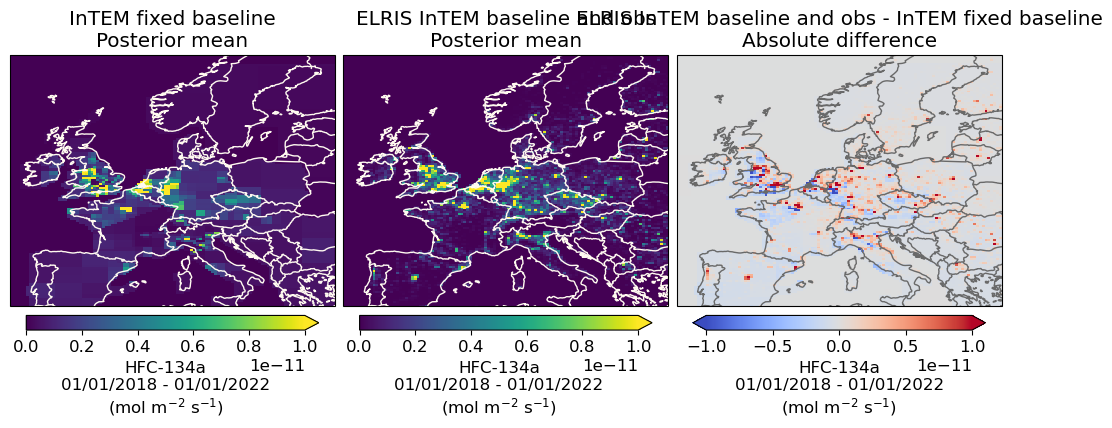

In [23]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')